In [5]:
import os
import numpy as np
import seaborn as sns
from matplotlib import gridspec
import matplotlib.pyplot as plt
from esg.models import SmithWilson, HullWhite

In [6]:
# 환경설정
plt.style.use('default')
plt.rc('figure', figsize=(10, 5))
plt.rc('axes', unicode_minus=False)
plt.rc('font', family='Malgun Gothic')
plt.style.use('seaborn')
os.makedirs('result', exist_ok=True)

In [7]:
# 데이터 입력
data = np.array([
    [0.25, 0.0041],
    [0.5, 0.0055],
    [0.75, 0.0061],
    [1, 0.0068],
    [2, 0.0090],
    [3, 0.0099],
    [5, 0.0140],
    [7, 0.0155],
    [10, 0.0174],
    [20, 0.0184]
])

X_train = data[:, 0]
y_train = data[:, 1]
ltfr, terminal = 0.052, 60

# SW 모델 생성 및 α 학습
sw = SmithWilson(np.log(1+ltfr), terminal)
sw.train(X_train, y_train)

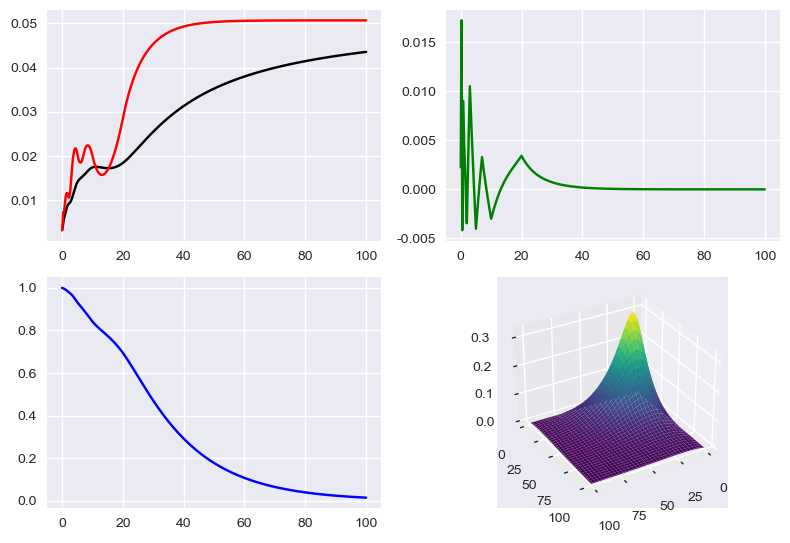

In [8]:
fig = plt.figure()
gs = gridspec.GridSpec(2, 2)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1], projection='3d')


t = np.arange(0, 100+1e-6, 1/12)
t2 = np.arange(1e-6, 100+2e-6, 1/12)
r = sw.spot(t)
f = sw.forward(t)
f2 = sw.forward(t, order=1)
# f22 = (sw.forward(t2)-sw.forward(t))/1e-6
p = sw.bond(t)
ax00.plot(t, r, c='black')
# ax00.scatter(X_train, y_train, c='black', marker='x')
ax00.plot(t, f, c='red')
ax01.plot(t, f2, c='green')
# ax01.plot(t, f22, c='green')
ax10.plot(t, p, c='blue')

x = np.arange(0, 101)
X = np.tile(x, (101, 1))
Y = np.transpose(X)
Z = sw._wilson(X, Y, sw._alpha)
ax11.plot_surface(X, Y, Z, cmap='viridis')
ax11.view_init(30, 60)

fig.tight_layout()
plt.savefig('result/spotinfo.png')
plt.show()

In [9]:
# alpha = [0.0001, 0.02082]
# sigma = [0.00457, 0.00490, 0.00651, 0.00631, 0.00465, 0.00562, 0.00405]
# hw = HullWhite(sw, alpha, sigma)

# fig = plt.figure(figsize=(12, 4))

# ax0 = fig.add_subplot(121)
# ax1 = fig.add_subplot(122)
# t = np.arange(0, 100+1e-6, 1/12)
# alp = np.array([hw.alpha(s) for s in t])
# sig = np.array([hw.sigma(s) for s in t])
# ax0.plot(t, alp, c='red')
# ax1.plot(t, sig, c='blue')

# fig.tight_layout()
# plt.show()

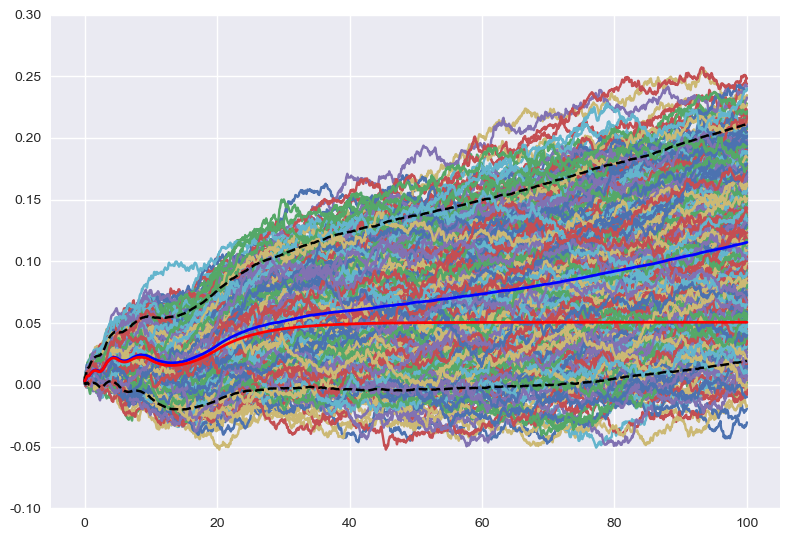

In [ ]:
for a in [0.0001, 0.02, 0.03, 0.05, 0.1]:
    alpha = [0.0001, a]
    sigma = [0.004306734, 0.004306734, 0.004813819, 0.005678626, 0.005528088, 0.005587264, 0.005011052]
    # alpha = [0.0001, 0.02082]
    # sigma = [0.00457, 0.00490, 0.00651, 0.00631, 0.00465, 0.00562, 0.00405]
    hw = HullWhite(sw, alpha, sigma)
    
    np.random.seed(20210616)    
    scen = hw.generate_scenario(t=100, n=1000)
    scen_mean = scen.mean(axis=1)
    vol = scen.std(axis=1)
    t = np.arange(0, 100+1e-6, 1/12)
    f = hw.curve.forward(t)
    
    # 시나리오
    fig = plt.figure()
    plt.plot(t, scen)
    plt.plot(t, scen_mean, c='blue', lw=2)
    plt.plot(t, scen_mean-1.96*vol, c='black', linestyle='--')
    plt.plot(t, scen_mean+1.96*vol, c='black', linestyle='--')
    plt.plot(t, f, c='red', lw=2)
    plt.ylim([-0.10, 0.30])
    plt.tight_layout()
    plt.savefig(f'result/scenario(a={a}).png')
    plt.show()
    plt.close()
    np.savetxt(f'result/scenario(a={a}).csv', scen.T, delimiter=',')
    
    # θ(t)
    fig = plt.figure()
    the1 = np.array([hw.curve.forward(s, 1)+hw.alpha(s)*hw.curve.forward(s) for s in t])
    the12 = np.array([hw.theta(s) for s in t])
    plt.plot(t, the1, label=r'$\frac{\partial}{{\partial}t}f(t)+{\alpha}(t)f(t)$')
    plt.plot(t, the12, label=r'${\theta}(t)$')
    plt.tight_layout()
    plt.legend()
    plt.savefig(f'result/theta(a={a}).png')
    plt.show()
    plt.close()
    np.savetxt(f'result/theta(a={a}).csv', the12, delimiter=',')
    
    print(f"a={a} 산출완료")